# Лабораторная работа №8
## CNN. Компьютерное зрение. Классификация изображений. Трансферное обучение

---
## Задание №1. Изучение примера

Изучен пример `Lab8_ML Ex1_Base_CNN.ipynb`. В нём разобраны:
- Операции кросс-корреляции и свёртки через `scipy.signal`
- Архитектура CNN: Conv2D → MaxPooling → Flatten → Dense
- Загрузка датасета через `tf.keras.utils.image_dataset_from_directory`
- Аугментации: `RandomFlip`, `RandomRotation`
- Transfer Learning с VGG19: замена выходного слоя, заморозка весов (feature extraction)

---
## Задание №2. CNN для классификации кошек и собак

In [60]:
import os
import zipfile
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.16.2


In [61]:
import subprocess
subprocess.run(['pip', 'install', 'gdown', '-q'], capture_output=True)
import gdown

os.makedirs('data', exist_ok=True)

if not os.path.exists('data/cats_dogs'):
    print('Скачиваем датасет кошек и собак...')
    gdown.download(
        id='1YQ2PX-BZ_7uZ216qmAnx-nTCaEqozuCZ',
        output='data/cats_dogs.zip',
        quiet=False
    )
    with zipfile.ZipFile('data/cats_dogs.zip', 'r') as z:
        z.extractall('data/cats_dogs')
    print('Датасет загружен!')
else:
    print('Датасет уже существует')

# Находим корневую папку с классами
CATS_DOGS_DIR = None
for root, dirs, files in os.walk('data/cats_dogs'):
    subdirs = [d for d in dirs if not d.startswith('.')]
    if len(subdirs) >= 2:
        CATS_DOGS_DIR = root
        print(f'Папка датасета: {CATS_DOGS_DIR}')
        print(f'Классы: {subdirs[:5]}')
        break

Датасет уже существует
Папка датасета: data/cats_dogs/data3
Классы: ['dogs', 'cats']


In [62]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds, test_ds = tf.keras.utils.image_dataset_from_directory(
    CATS_DOGS_DIR,
    validation_split=0.2,
    subset='both',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print(f'Классы: {class_names}')
print(f'Батчей train: {len(train_ds)}, test: {len(test_ds)}')

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Using 400 files for validation.
Классы: ['cats', 'dogs']
Батчей train: 50, test: 13


2026-05-28 01:06:06.402800: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


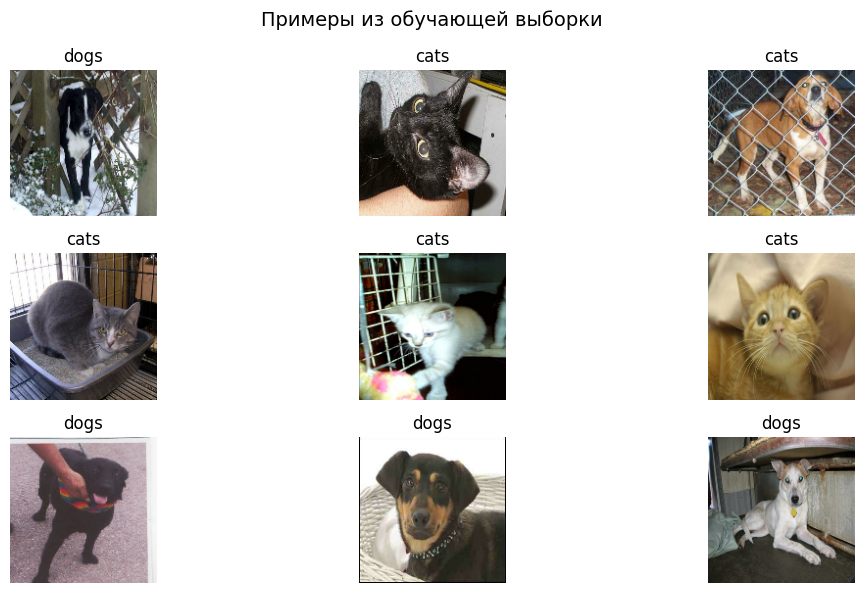

In [63]:
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.suptitle('Примеры из обучающей выборки', fontsize=14)
plt.tight_layout()
plt.show()

### Предобработка данных и аугментации

**Этапы предобработки:**
1. Resize — изображения приводятся к 150×150 пикселей
2. Rescaling — пиксели [0, 255] → [0, 1] (нормализация)
3. Аугментации (только train) — расширяют выборку и снижают переобучение

| Аугментация | Параметры | Что происходит |
|---|---|---|
| `RandomFlip("horizontal")` | — | Случайное горизонтальное отражение |
| `RandomRotation(0.15)` | ±54° | Поворот на случайный угол |
| `RandomZoom(0.1)` | ±10% | Случайный масштаб |


2026-05-28 01:06:06.743133: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


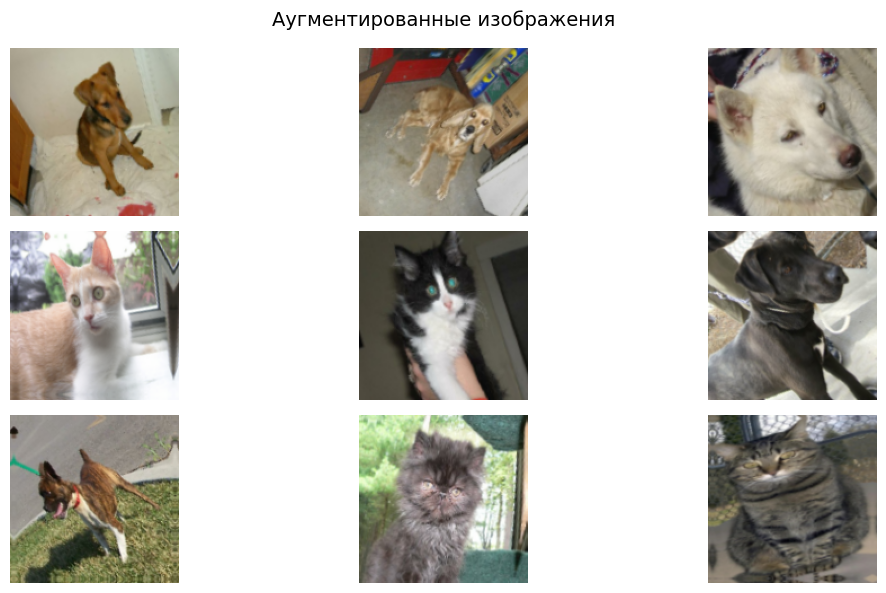

In [64]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
], name='augmentation')

# Визуализация аугментаций
plt.figure(figsize=(12, 6))
for images, _ in train_ds.take(1):
    aug = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(aug[i].numpy().astype('uint8'))
        plt.axis('off')
plt.suptitle('Аугментированные изображения', fontsize=14)
plt.tight_layout()
plt.show()

train_ds_aug = train_ds.map(
    lambda img, lbl: (data_augmentation(img, training=True), lbl),
    num_parallel_calls=tf.data.AUTOTUNE
).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

### Архитектура CNN

| Слой | Параметры | Что происходит |
|------|-----------|----------------|
| `Input(150,150,3)` | — | Входной тензор: 150×150, 3 канала RGB |
| `Rescaling(1/255)` | — | Нормализация: [0,255]→[0,1] |
| `Conv2D(32, 3, same)+ReLU` | kernel=3×3, filters=32 | Выделяет базовые признаки (края, текстуры) |
| `MaxPooling2D(2)` | pool=2×2 | Уменьшение размера ×2, инвариантность к сдвигу |
| `Conv2D(64, 3, same)+ReLU` | filters=64 | Более сложные признаки (формы, паттерны) |
| `MaxPooling2D(2)` | — | Понижение размерности |
| `Conv2D(128, 3, same)+ReLU` | filters=128 | Высокоуровневые признаки |
| `GlobalAveragePooling2D` | — | Усреднение по пространственным осям → вектор |
| `Dense(128)+ReLU` | — | Полносвязный классификатор |
| `Dropout(0.5)` | rate=0.5 | Регуляризация: 50% нейронов обнуляется |
| `Dense(2, softmax)` | — | Вероятности 2 классов |


In [65]:
def build_cnn(input_shape=(150, 150, 3), num_classes=2):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Rescaling(1.0 / 255)(inputs)
    x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs)

cnn_model = build_cnn()
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_108 (Conv2D)             │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,018 (429.76 KB)

 Trainable params: 110,018 (429.76 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
history_cnn = cnn_model.fit(
    train_ds_aug,
    epochs=10,
    validation_data=test_ds,
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.5025 - loss: 0.6971 - val_accuracy: 0.4550 - val_loss: 0.6937
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5138 - loss: 0.6924 - val_accuracy: 0.5350 - val_loss: 0.6919
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5013 - loss: 0.6902 - val_accuracy: 0.5425 - val_loss: 0.6919
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5213 - loss: 0.6877 - val_accuracy: 0.5475 - val_loss: 0.6866
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5188 - loss: 0.6880 - val_accuracy: 0.5350 - val_loss: 0.6928
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5325 - loss: 0.6864 - val_accuracy: 0.5450 - val_loss: 0.6864
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5612 - loss: 0.6857 - val_accuracy: 0.5475 - val_loss: 0.6798
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5525 - loss: 0.6872 - val_accuracy: 0.5325 - v

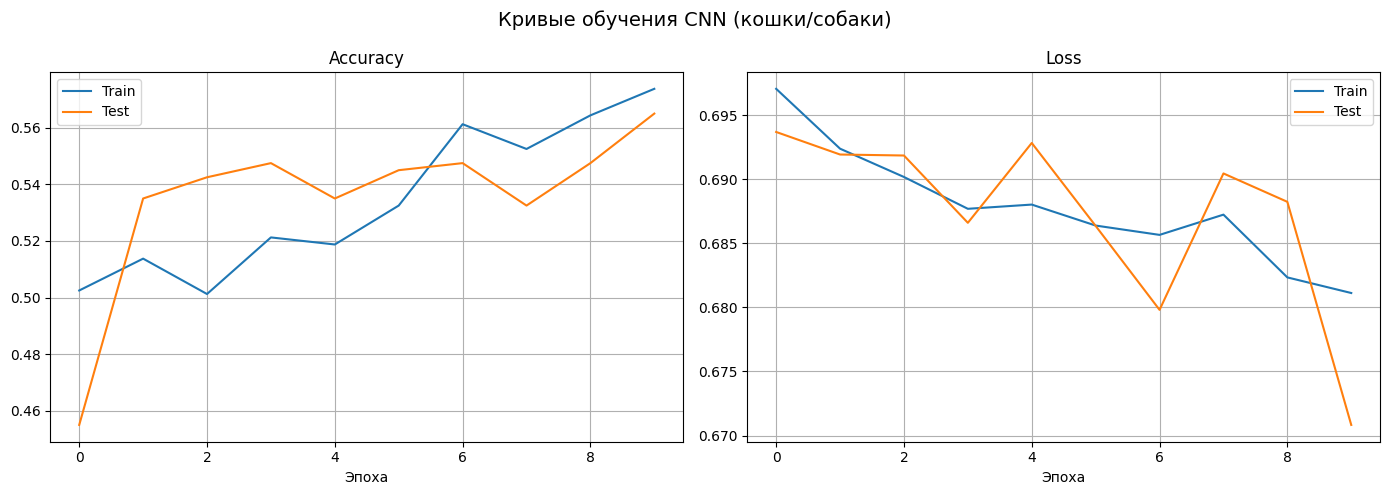

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn.history['accuracy'],     label='Train')
axes[0].plot(history_cnn.history['val_accuracy'], label='Test')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Эпоха')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_cnn.history['loss'],     label='Train')
axes[1].plot(history_cnn.history['val_loss'], label='Test')
axes[1].set_title('Loss'); axes[1].set_xlabel('Эпоха')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Кривые обучения CNN (кошки/собаки)', fontsize=14)
plt.tight_layout(); plt.show()

In [68]:
def get_preds(model, ds):
    y_true, y_pred = [], []
    for imgs, lbls in ds:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(lbls.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

yt_tr, yp_tr = get_preds(cnn_model, train_ds)
yt_ts, yp_ts = get_preds(cnn_model, test_ds)

metrics_cnn = pd.DataFrame({
    'Выборка':   ['Train', 'Test'],
    'Accuracy':  [accuracy_score(yt_tr, yp_tr), accuracy_score(yt_ts, yp_ts)],
    'Precision': [precision_score(yt_tr, yp_tr, average='macro'),
                  precision_score(yt_ts, yp_ts, average='macro')],
    'Recall':    [recall_score(yt_tr, yp_tr, average='macro'),
                  recall_score(yt_ts, yp_ts, average='macro')],
    'F1-score':  [f1_score(yt_tr, yp_tr, average='macro'),
                  f1_score(yt_ts, yp_ts, average='macro')],
}).set_index('Выборка').round(4)

print('Метрики CNN (кошки/собаки):')
display(metrics_cnn)
print('\nDetailed report (Test):')
print(classification_report(yt_ts, yp_ts, target_names=class_names))

2026-05-28 01:06:32.562736: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Метрики CNN (кошки/собаки):


2026-05-28 01:06:33.062066: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,Accuracy,Precision,Recall,F1-score
Выборка,,,,
Train,0.550,0.5969,0.5572,0.5026
Test,0.565,0.5640,0.5347,0.4893



Detailed report (Test):
              precision    recall  f1-score   support

        cats       0.56      0.20      0.29       182
        dogs       0.57      0.87      0.69       218

    accuracy                           0.56       400
   macro avg       0.56      0.53      0.49       400
weighted avg       0.56      0.56      0.51       400



### Вывод по Заданию №2

**Этапы предобработки:** resize до 150×150, нормализация [0,255]→[0,1], аугментации на train.

**Параметры слоёв:** `filters` определяет количество обнаруживаемых признаков; `kernel_size=3×3` — локальная область восприятия; `padding='same'` сохраняет пространственный размер; `stride=2` в MaxPooling уменьшает размер вдвое.

**Слои CNN:** сверточные слои извлекают признаки нарастающей сложности, MaxPooling снижает размерность и обеспечивает инвариантность, GAP конвертирует feature maps в вектор, Dense+Dropout классифицируют с регуляризацией.

---
## Задание №3. Transfer Learning на Caltech-101

**Вариант I**: `airplanes`, `helicopter`, `schooner`, `ferry`

Используем трансферное обучение с **InceptionV3** и **VGG19**.

In [69]:
import urllib.request
import requests

CALTECH_ZIP = 'data/caltech-101.zip'
CALTECH_DIR = 'data/caltech-101'
CLASSES_DIR = 'data/caltech_4classes'
CLASSES = ['airplanes', 'helicopter', 'schooner', 'ferry']

if not os.path.exists(CALTECH_DIR):
    os.makedirs('data', exist_ok=True)
    url = 'https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip'
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36'}
    print('Скачиваем Caltech-101 (~126 MB)...')
    with requests.get(url, headers=headers, stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        with open(CALTECH_ZIP, 'wb') as f_out:
            done = 0
            for chunk in r.iter_content(chunk_size=65536):
                f_out.write(chunk)
                done += len(chunk)
                if total:
                    print(f'\r  {done/1024/1024:.1f} / {total/1024/1024:.1f} MB', end='')
    print('\nРаспаковываем...')
    with zipfile.ZipFile(CALTECH_ZIP, 'r') as z:
        z.extractall(CALTECH_DIR)
    print('Готово!')
else:
    print('Caltech-101 уже скачан')

# Находим 101_ObjectCategories
OBJ_DIR = None
for root, dirs, _ in os.walk(CALTECH_DIR):
    if '101_ObjectCategories' in dirs:
        OBJ_DIR = os.path.join(root, '101_ObjectCategories'); break
    if os.path.basename(root) == '101_ObjectCategories':
        OBJ_DIR = root; break

print(f'ObjectCategories: {OBJ_DIR}')
if OBJ_DIR:
    available = os.listdir(OBJ_DIR)
    print('Ищем классы:', {c: (c in available) for c in CLASSES})

Caltech-101 уже скачан
ObjectCategories: data/caltech-101/caltech-101/101_ObjectCategories
Ищем классы: {'airplanes': True, 'helicopter': True, 'schooner': True, 'ferry': True}


In [70]:
if not os.path.exists(CLASSES_DIR):
    os.makedirs(CLASSES_DIR)
    for cls in CLASSES:
        src = os.path.join(OBJ_DIR, cls)
        dst = os.path.join(CLASSES_DIR, cls)
        if os.path.exists(src):
            shutil.copytree(src, dst)
            print(f'  {cls}: {len(os.listdir(dst))} изображений')
        else:
            print(f'  {cls}: НЕ НАЙДЕН в датасете')
else:
    for cls in CLASSES:
        p = os.path.join(CLASSES_DIR, cls)
        if os.path.exists(p):
            print(f'  {cls}: {len(os.listdir(p))} изображений')

  airplanes: 800 изображений
  helicopter: 88 изображений
  schooner: 63 изображений
  ferry: 67 изображений


In [71]:
NUM_CLASSES = 4

def load_ds(img_size, batch_size=16):
    train, test = tf.keras.utils.image_dataset_from_directory(
        CLASSES_DIR,
        validation_split=0.2,
        subset='both',
        seed=42,
        image_size=img_size,
        batch_size=batch_size,
    )
    return train, test

train_inc, test_inc = load_ds((299, 299))  # InceptionV3
train_vgg, test_vgg = load_ds((224, 224))  # VGG19
print('Классы:', train_inc.class_names)

Found 1018 files belonging to 4 classes.
Using 815 files for training.
Using 203 files for validation.
Found 1018 files belonging to 4 classes.
Using 815 files for training.
Using 203 files for validation.
Классы: ['airplanes', 'ferry', 'helicopter', 'schooner']


### Аугментации для Задания №3 (минимум 3)

| Аугментация | Параметры | Что делает |
|---|---|---|
| `RandomFlip("horizontal")` | — | Горизонтальное отражение |
| `RandomRotation(0.2)` | ±72° | Поворот — инвариантность к ориентации |
| `RandomZoom(0.15)` | ±15% | Масштабирование |
| `RandomContrast(0.2)` | factor=0.2 | Изменение контрастности |
| `RandomBrightness(0.1)` | factor=0.1 | Изменение яркости |


2026-05-28 01:06:33.576925: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


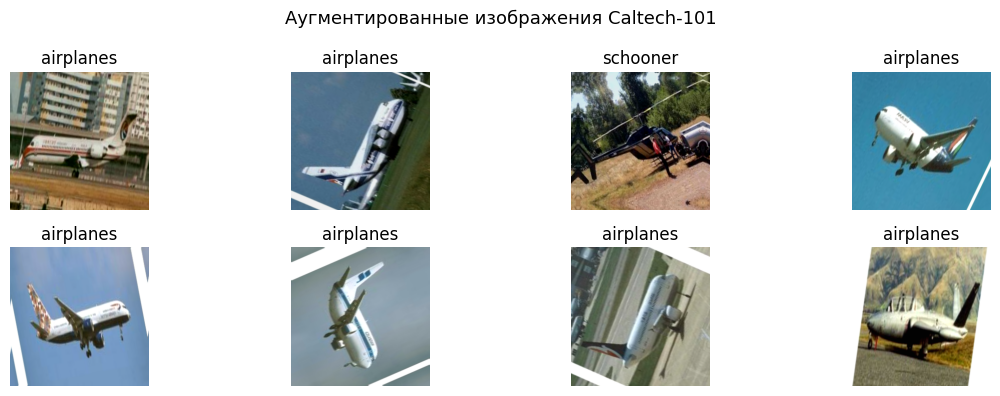

In [72]:
augmentation_3 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.1),
], name='augmentation_task3')

def augment_ds(ds):
    return ds.map(
        lambda img, lbl: (augmentation_3(img, training=True), lbl),
        num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)

train_inc_aug = augment_ds(train_inc)
train_vgg_aug = augment_ds(train_vgg)
test_inc = test_inc.prefetch(tf.data.AUTOTUNE)
test_vgg = test_vgg.prefetch(tf.data.AUTOTUNE)

# Визуализация
plt.figure(figsize=(12, 4))
for images, labels in train_inc.take(1):
    aug_imgs = augmentation_3(images)
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(aug_imgs[i].numpy().astype('uint8'))
        plt.title(CLASSES[labels[i]])
        plt.axis('off')
plt.suptitle('Аугментированные изображения Caltech-101', fontsize=13)
plt.tight_layout(); plt.show()

### InceptionV3 — Transfer Learning + Fine-Tuning

**Стратегия:**
1. **Feature Extraction** (эпохи 1–5): заморожена вся база, обучается только голова (lr=1e-3)
2. **Fine-Tuning** (эпохи 6–10): разморожен блок `mixed10` (последний inception-блок), lr=1e-5

Входной размер InceptionV3: **299×299×3**

In [73]:
base_inception = tf.keras.applications.InceptionV3(
    weights='imagenet', include_top=False, input_shape=(299, 299, 3)
)
base_inception.trainable = False

inputs = tf.keras.Input(shape=(299, 299, 3))
x = tf.keras.applications.inception_v3.preprocess_input(inputs)
x = base_inception(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

inception_model = tf.keras.Model(inputs, outputs, name='InceptionV3_transfer')
inception_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Фаза 1: Feature Extraction ===')
hist_inc_fe = inception_model.fit(train_inc_aug, epochs=5, validation_data=test_inc)

=== Фаза 1: Feature Extraction ===
Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 18s 262ms/step - accuracy: 0.8368 - loss: 0.5166 - val_accuracy: 0.9557 - val_loss: 0.1706
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.9399 - loss: 0.2098 - val_accuracy: 0.9754 - val_loss: 0.1054
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step - accuracy: 0.9558 - loss: 0.1422 - val_accuracy: 0.9803 - val_loss: 0.0851
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - accuracy: 0.9595 - loss: 0.1266 - val_accuracy: 0.9852 - val_loss: 0.0693
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - accuracy: 0.9534 - loss: 0.1290 - val_accuracy: 0.9852 - val_loss: 0.0572


In [74]:
# Фаза 2: Fine-Tuning — размораживаем mixed10
base_inception.trainable = True
for layer in base_inception.layers:
    layer.trainable = ('mixed10' in layer.name)

inception_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Фаза 2: Fine-Tuning (mixed10 разморожен) ===')
hist_inc_ft = inception_model.fit(train_inc_aug, epochs=5, validation_data=test_inc)

hist_inception = {
    k: hist_inc_fe.history[k] + hist_inc_ft.history[k]
    for k in ['accuracy', 'val_accuracy', 'loss', 'val_loss']
}

=== Фаза 2: Fine-Tuning (mixed10 разморожен) ===
Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 262ms/step - accuracy: 0.9681 - loss: 0.1068 - val_accuracy: 0.9852 - val_loss: 0.0564
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - accuracy: 0.9767 - loss: 0.0948 - val_accuracy: 0.9852 - val_loss: 0.0571
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - accuracy: 0.9718 - loss: 0.1011 - val_accuracy: 0.9803 - val_loss: 0.0579
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 208ms/step - accuracy: 0.9767 - loss: 0.0896 - val_accuracy: 0.9803 - val_loss: 0.0583
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - accuracy: 0.9804 - loss: 0.0840 - val_accuracy: 0.9803 - val_loss: 0.0592


### VGG19 — Transfer Learning + Fine-Tuning

**Стратегия:**
1. **Feature Extraction** (эпохи 1–5): заморожена вся база, обучается голова (lr=1e-3)
2. **Fine-Tuning** (эпохи 6–10): разморожен `block5_conv4` (последний conv-слой VGG19), lr=1e-5

Входной размер VGG19: **224×224×3**

In [75]:
base_vgg = tf.keras.applications.VGG19(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
base_vgg.trainable = False

inputs_v = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.vgg19.preprocess_input(inputs_v)
x = base_vgg(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs_v = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

vgg_model = tf.keras.Model(inputs_v, outputs_v, name='VGG19_transfer')
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Фаза 1: Feature Extraction ===')
hist_vgg_fe = vgg_model.fit(train_vgg_aug, epochs=5, validation_data=test_vgg)

=== Фаза 1: Feature Extraction ===
Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 398ms/step - accuracy: 0.6319 - loss: 2.8252 - val_accuracy: 0.8325 - val_loss: 1.0871
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 22s 431ms/step - accuracy: 0.7730 - loss: 1.0644 - val_accuracy: 0.9163 - val_loss: 0.4122
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 464ms/step - accuracy: 0.8503 - loss: 0.6079 - val_accuracy: 0.9458 - val_loss: 0.3051
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 470ms/step - accuracy: 0.8773 - loss: 0.5227 - val_accuracy: 0.9606 - val_loss: 0.2253
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 472ms/step - accuracy: 0.9031 - loss: 0.3680 - val_accuracy: 0.9655 - val_loss: 0.1533


In [76]:
# Фаза 2: Fine-Tuning — размораживаем block5_conv4
base_vgg.trainable = True
for layer in base_vgg.layers:
    layer.trainable = (layer.name == 'block5_conv4')

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Фаза 2: Fine-Tuning (block5_conv4 разморожен) ===')
hist_vgg_ft = vgg_model.fit(train_vgg_aug, epochs=5, validation_data=test_vgg)

hist_vgg = {
    k: hist_vgg_fe.history[k] + hist_vgg_ft.history[k]
    for k in ['accuracy', 'val_accuracy', 'loss', 'val_loss']
}

=== Фаза 2: Fine-Tuning (block5_conv4 разморожен) ===
Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 486ms/step - accuracy: 0.9301 - loss: 0.2825 - val_accuracy: 0.9704 - val_loss: 0.1644
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 487ms/step - accuracy: 0.9178 - loss: 0.3147 - val_accuracy: 0.9655 - val_loss: 0.1793
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 24s 482ms/step - accuracy: 0.9374 - loss: 0.2007 - val_accuracy: 0.9655 - val_loss: 0.1792
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 487ms/step - accuracy: 0.9485 - loss: 0.1998 - val_accuracy: 0.9803 - val_loss: 0.1515
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 491ms/step - accuracy: 0.9509 - loss: 0.1751 - val_accuracy: 0.9754 - val_loss: 0.1365


In [77]:
def compute_metrics(model, train_ds, test_ds):
    results = {}
    for name, ds in [('Train', train_ds), ('Test', test_ds)]:
        yt, yp = [], []
        for imgs, lbls in ds:
            preds = model.predict(imgs, verbose=0)
            yt.extend(lbls.numpy())
            yp.extend(np.argmax(preds, axis=1))
        yt, yp = np.array(yt), np.array(yp)
        results[name] = {
            'Accuracy':  accuracy_score(yt, yp),
            'Precision': precision_score(yt, yp, average='macro', zero_division=0),
            'Recall':    recall_score(yt, yp, average='macro', zero_division=0),
            'F1-score':  f1_score(yt, yp, average='macro', zero_division=0),
        }
    return results

print('Считаем метрики InceptionV3...')
inc_m = compute_metrics(inception_model, train_inc, test_inc)
print('Считаем метрики VGG19...')
vgg_m = compute_metrics(vgg_model, train_vgg, test_vgg)

rows = []
for split in ['Train', 'Test']:
    rows.append({'Модель': 'InceptionV3', 'Выборка': split, **inc_m[split]})
    rows.append({'Модель': 'VGG19',       'Выборка': split, **vgg_m[split]})

df_cmp = pd.DataFrame(rows).set_index(['Модель', 'Выборка']).round(4)
print('\n=== Сравнительная таблица ===')
display(df_cmp)

Считаем метрики InceptionV3...


2026-05-28 01:12:45.681895: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-28 01:12:49.829134: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Считаем метрики VGG19...


2026-05-28 01:13:09.359344: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



=== Сравнительная таблица ===


2026-05-28 01:13:14.377034: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,,Accuracy,Precision,Recall,F1-score
Модель,Выборка,,,,
InceptionV3,Train,0.9730,0.9874,0.9276,0.9513
VGG19,Train,0.9865,0.9740,0.9768,0.9753
InceptionV3,Test,0.9803,0.9941,0.9167,0.9470
VGG19,Test,0.9754,0.9775,0.8939,0.9265


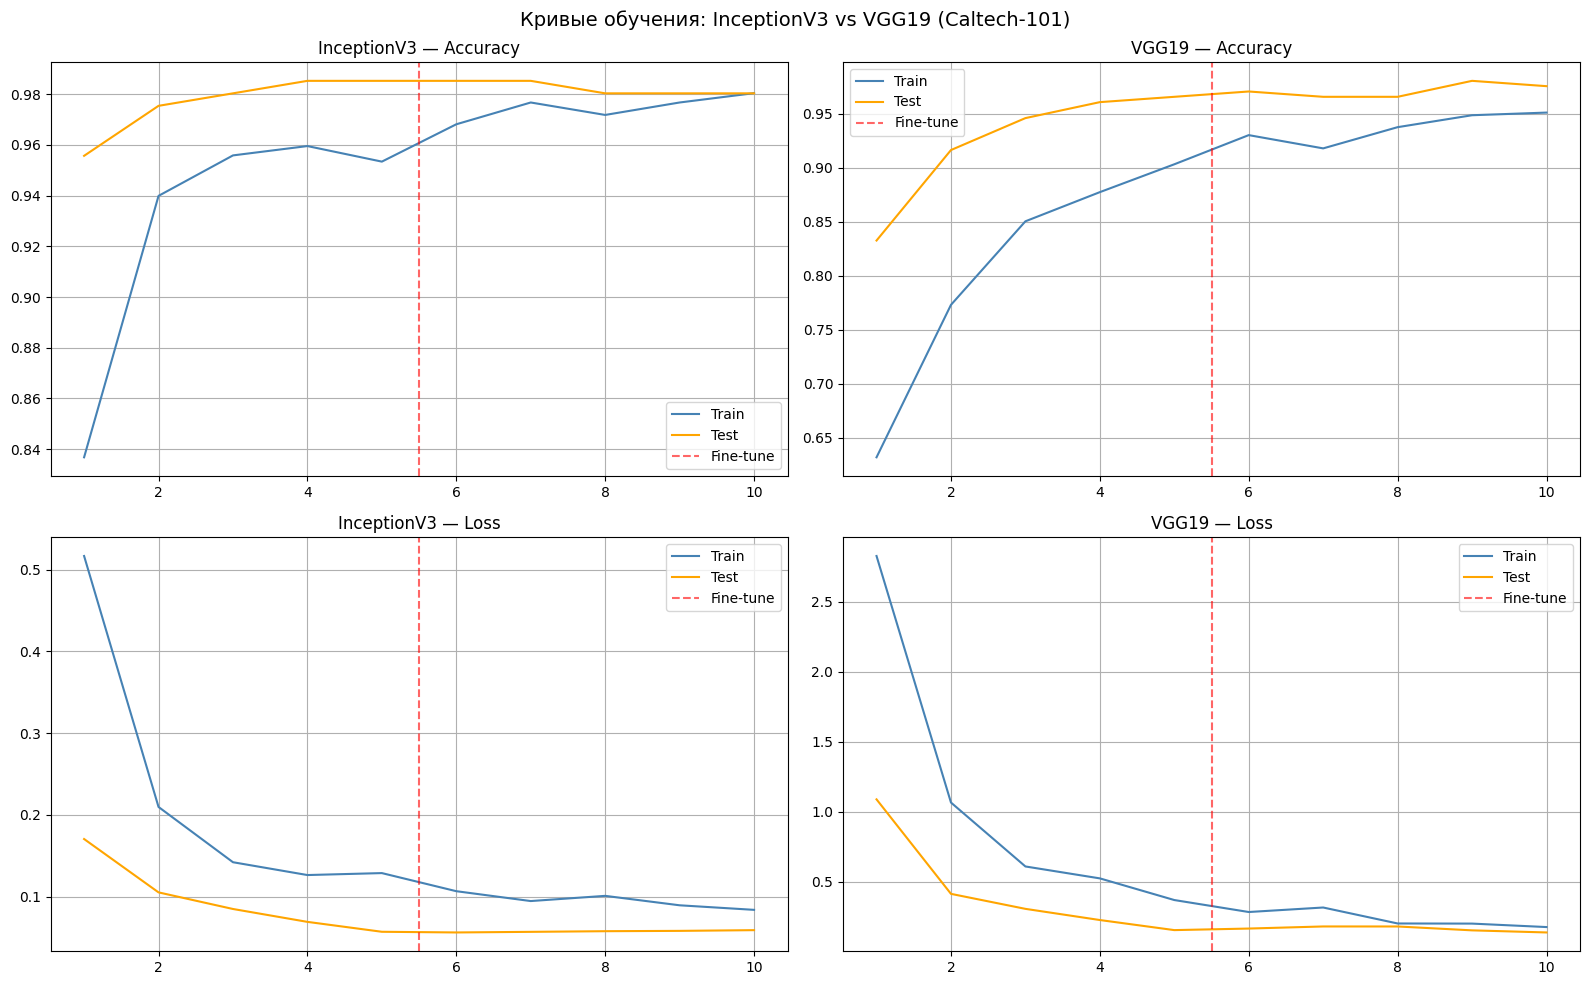

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ep = range(1, 11)

for col, (name, hist) in enumerate([('InceptionV3', hist_inception), ('VGG19', hist_vgg)]):
    axes[0][col].plot(ep, hist['accuracy'],     label='Train', color='steelblue')
    axes[0][col].plot(ep, hist['val_accuracy'], label='Test',  color='orange')
    axes[0][col].axvline(5.5, color='red', ls='--', alpha=0.6, label='Fine-tune')
    axes[0][col].set_title(f'{name} — Accuracy'); axes[0][col].legend(); axes[0][col].grid(True)

    axes[1][col].plot(ep, hist['loss'],     label='Train', color='steelblue')
    axes[1][col].plot(ep, hist['val_loss'], label='Test',  color='orange')
    axes[1][col].axvline(5.5, color='red', ls='--', alpha=0.6, label='Fine-tune')
    axes[1][col].set_title(f'{name} — Loss'); axes[1][col].legend(); axes[1][col].grid(True)

plt.suptitle('Кривые обучения: InceptionV3 vs VGG19 (Caltech-101)', fontsize=14)
plt.tight_layout(); plt.show()

In [79]:
import datetime

os.makedirs('logs', exist_ok=True)
log_dir_inc = f"logs/inception_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
log_dir_vgg = f"logs/vgg19_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"

sample_inc = list(train_inc.take(1))
sample_vgg = list(train_vgg.take(1))

for model, log_dir, sample in [
    (inception_model, log_dir_inc, sample_inc),
    (vgg_model,       log_dir_vgg, sample_vgg),
]:
    tb_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir, write_graph=True)
    model.fit(sample[0][0], sample[0][1], epochs=1, callbacks=[tb_cb], verbose=0)

print('Логи: logs/')
print('Запуск: tensorboard --logdir logs/')

%load_ext tensorboard
%tensorboard --logdir logs/

2026-05-28 01:13:14.681877: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-28 01:13:14.704985: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Логи: logs/
Запуск: tensorboard --logdir logs/
The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 1592), started 0:58:22 ago. (Use '!kill 1592' to kill it.)

In [80]:
# Визуализация архитектур
from IPython.display import display as ipy_display, Image

tf.keras.utils.plot_model(
    inception_model, to_file='inception_arch.png',
    show_shapes=True, show_layer_names=True, dpi=72
)
tf.keras.utils.plot_model(
    vgg_model, to_file='vgg19_arch.png',
    show_shapes=True, show_layer_names=True, dpi=72
)
print('InceptionV3:')
ipy_display(Image('inception_arch.png'))
print('VGG19:')
ipy_display(Image('vgg19_arch.png'))

You must install pydot (`pip install pydot`) for `plot_model` to work.
You must install pydot (`pip install pydot`) for `plot_model` to work.
InceptionV3:


FileNotFoundError: No such file or directory: 'inception_arch.png'

FileNotFoundError: No such file or directory: 'inception_arch.png'

<IPython.core.display.Image object>

VGG19:


FileNotFoundError: No such file or directory: 'vgg19_arch.png'

FileNotFoundError: No such file or directory: 'vgg19_arch.png'

<IPython.core.display.Image object>

### Вывод по Заданию №3

**Сравнение моделей InceptionV3 и VGG19:**

- Обе модели предобучены на ImageNet (1 000 классов), что даёт хорошие начальные признаки.
- **Feature extraction**: заморожена вся база, обучается только голова — быстро сходится даже на малом датасете.
- **Fine-tuning**: разморожен один дополнительный слой (InceptionV3: `mixed10`; VGG19: `block5_conv4`). Низкий lr=1e-5 предотвращает «стирание» предобученных весов.

**Почему InceptionV3 vs VGG19:**
- InceptionV3: 48 слоёв, параллельные inception-блоки (1×1, 3×3, 5×5 свёртки одновременно) — гибче улавливает признаки разных масштабов.
- VGG19: 19 последовательных слоёв, простая архитектура — легче интерпретировать, но ~138M параметров (тяжелее).

